# Отбор и селекция признаков

In [71]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder # библиотека для работы с категориальными признаками
from sklearn.linear_model import LinearRegression

# Загрузка данных

In [67]:
# %%capture
# !wget https://www.dropbox.com/s/64ol9q9ssggz6f1/data_ford_price.xlsx

In [72]:
ford_price_data = pd.read_excel('Data/data_ford_price.xlsx')
display(ford_price_data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7017 entries, 0 to 7016
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   price         7017 non-null   int64  
 1   year          7017 non-null   int64  
 2   condition     7017 non-null   int64  
 3   cylinders     7017 non-null   int64  
 4   odometer      7017 non-null   int64  
 5   title_status  7017 non-null   object 
 6   transmission  7017 non-null   object 
 7   drive         6626 non-null   object 
 8   size          5453 non-null   object 
 9   lat           7017 non-null   float64
 10  long          7017 non-null   float64
 11  weather       6837 non-null   float64
dtypes: float64(3), int64(5), object(4)
memory usage: 658.0+ KB


None

Обратимся к нашим данным. Нас просят предсказать цену автомобиля. Для обучения модели выделим целевой столбец:

In [73]:
X = ford_price_data.drop(columns='price')
y = ford_price_data['price'] # Целевой признак

# Предобработка

Попробуем применить линейную регрессию на «сырых» данных:

In [74]:
lr = LinearRegression()
lr.fit(X, y)

ValueError: could not convert string to float: 'clean'

Мы получим ошибку с комментарием о том, что не удалось превратить строковое значение в число с плавающей точкой (float).

### Сторонний пример

__LabelBinarizer__ — это инструмент для бинаризации категориальных признаков, т.е. он переводит категориальные данные (строки) в one-hot кодировку (или близкую к ней).

In [75]:
from sklearn.preprocessing  import LabelBinarizer
 
lb = LabelBinarizer()
 
education = ['нет', 'начальное', 'среднее', 'BSc', 'MSc', 'начальное', 'PhD']
lb.fit(education)
 
print('категории:', lb.classes_) 
lb.transform(['нет', 'MSc'])

категории: ['BSc' 'MSc' 'PhD' 'начальное' 'нет' 'среднее']


array([[0, 0, 0, 0, 1, 0],
       [0, 1, 0, 0, 0, 0]])

Выводим категориальные признаки:

In [76]:
columns_to_change = ['cylinders', 'title_status', 'transmission', 'drive', 'size']

for column in columns_to_change:
    print('Число уникальных значений призкака {}: '.format(column), ford_price_data[column].nunique())

Число уникальных значений призкака cylinders:  6
Число уникальных значений призкака title_status:  5
Число уникальных значений призкака transmission:  3
Число уникальных значений призкака drive:  3
Число уникальных значений призкака size:  4


Поскольку, судя по выводу выше у нас не много категорий в признаках (условно до 15 в каждом), значит мы можем смело использовать OneHotEncoder, кроме того признаки номинальные.

In [77]:
# 1. Преобразование
encoder = OneHotEncoder()
# 'учим' и сразу применяем преобразование к выборке, результат переводим в массив
data_onehot = encoder.fit_transform(ford_price_data[columns_to_change]).toarray()
# запишем полученные названия новых колонок в отдельную переменную
column_names = encoder.get_feature_names_out(columns_to_change)
print(column_names)

# 2. Создаём датафрейм из one-hot матрицы
df_onehot = pd.DataFrame(data_onehot, columns=column_names, index=ford_price_data.index)

# 3. Удаляем исходные категориальные признаки
ford_price_data_clean = ford_price_data.drop(columns=columns_to_change)

# 4. Объединяем закодированные признаки с остальными
final_df = pd.concat([ford_price_data_clean, df_onehot], axis=1)

['cylinders_3' 'cylinders_4' 'cylinders_5' 'cylinders_6' 'cylinders_8'
 'cylinders_10' 'title_status_clean' 'title_status_lien'
 'title_status_missing' 'title_status_rebuilt' 'title_status_salvage'
 'transmission_automatic' 'transmission_manual' 'transmission_other'
 'drive_4wd' 'drive_fwd' 'drive_rwd' 'drive_nan' 'size_compact'
 'size_full-size' 'size_mid-size' 'size_sub-compact' 'size_nan']


In [78]:
final_df.shape

(7017, 30)

<img src='Images/ml_01.png'>

<img src='Images/ml_02.png'>

По аналогии с тем, как мы разбиваем нашу выборку на X (train) и y (test или validation) подгонка кодировщика (fit) происходит на обучающей выборке (X), а трансформация — на обучающей и на тестовой (transform) - X, y.

Почему так? Потому что наша обученная модель не должна видеть данные, которые подаются в неё на тесте. Только так мы можем судить о том, что модель обучена качественно. То же самое и с кодировкой.

<Axes: >

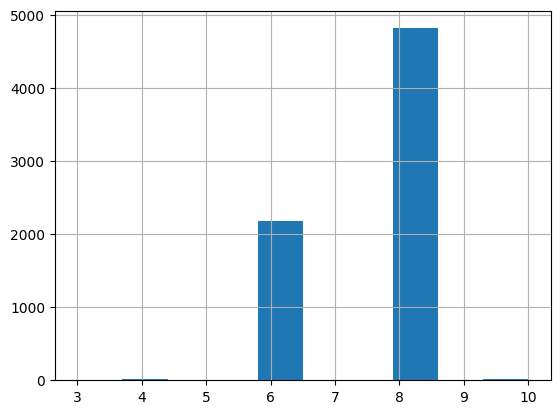

In [79]:
ford_price_data['cylinders'].hist()

<Axes: >

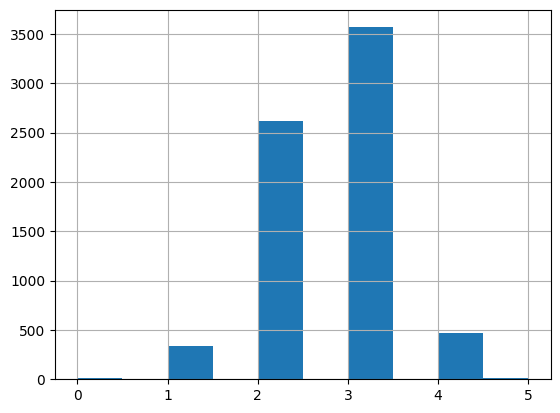

In [80]:
ford_price_data['condition'].hist()

Важно производить кодирование номинальных признаков (признак 'cylinders'), даже если они уже представлены в числовом формате, так как, в отличие от порядковых признаков (признак 'condition'), категории номинальных являются независимыми. В случае порядкового кодирования таких признаков мы вносим искусственные закономерности в данные (например, чем больше числовой код цилиндров, тем лучше, хотя это необязательно так).

In [81]:
final_df

,price,year,condition,odometer,lat,long,weather,cylinders_3,cylinders_4,cylinders_5,...,transmission_other,drive_4wd,drive_fwd,drive_rwd,drive_nan,size_compact,size_full-size,size_mid-size,size_sub-compact,size_nan
0,43900,2016,4,43500,36.471500,-82.483400,59.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,15490,2009,2,98131,40.468826,-74.281734,52.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,2495,2002,2,201803,42.477134,-82.949564,45.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,1300,2000,1,170305,40.764373,-82.349503,49.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,13865,2010,3,166062,49.210949,-123.114720,NaN,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7012,22500,2015,3,23500,32.680700,-117.169800,59.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
7013,5975,2005,2,0,38.213303,-85.785762,50.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
7014,9999,2006,3,161514,37.609783,-120.995406,59.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
7015,10900,2011,2,164000,43.140600,-93.385000,47.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
